In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_two_images(img1_path, img2_path,
                    title1="Original",
                    title2="XAI",
                    save_path=None):

    img1 = mpimg.imread(img1_path)
    img2 = mpimg.imread(img2_path)

    fig, axes = plt.subplots(1, 2, figsize=(7, 4))

    # Coluna 1
    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis("off")

    # Coluna 2
    axes[1].imshow(img2)
    axes[1].set_title(title2)
    axes[1].axis("off")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def plot_three_images(img1_path, img2_path, img3_path,
                      title1="Original",
                      title2="XAI ResNet",
                      title3="XAI Swin",
                      save_path=None):

    # Carrega imagens
    img1 = mpimg.imread(img1_path)
    img2 = mpimg.imread(img2_path)
    img3 = mpimg.imread(img3_path)

    # Cria figura
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1 — Imagem original
    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis("off")

    # 2 — XAI ResNet
    axes[1].imshow(img2)
    axes[1].set_title(title2)
    axes[1].axis("off")

    # 3 — XAI Swin
    axes[2].imshow(img3)
    axes[2].set_title(title3)
    axes[2].axis("off")

    plt.tight_layout()

    # Salvar se quiser
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


In [9]:
img_base_nii= r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_annot_nii\train\infected\2022_03_21_11_02_58_05_cell0012.png"
xai_gradcam_resnet= r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_resnet_fold5_nii\gradcam\2022_03_21_11_05_09_12_cell0001_gradcam.png"
xai_gradcam_siwn = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_swin_fold2_nii\gradcam\2022_03_21_11_05_09_12_cell0001_gradcam.png"
xai_ig_resnet = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_resnet_fold5_nii\integrated_gradients\2022_03_21_11_05_09_12_cell0001_ig.png"
xai_ig_swin = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_swin_fold2_nii\integrated_gradients\2022_03_21_11_05_09_12_cell0001_ig.png"
xai_occ_resnet = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_resnet_fold5_nii\occlusion\2022_03_21_11_05_09_12_cell0001_occ.png"
xai_occ_swin = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\xai_swin_fold2_nii\occlusion\2022_03_21_11_05_09_12_cell0001_occ.png"

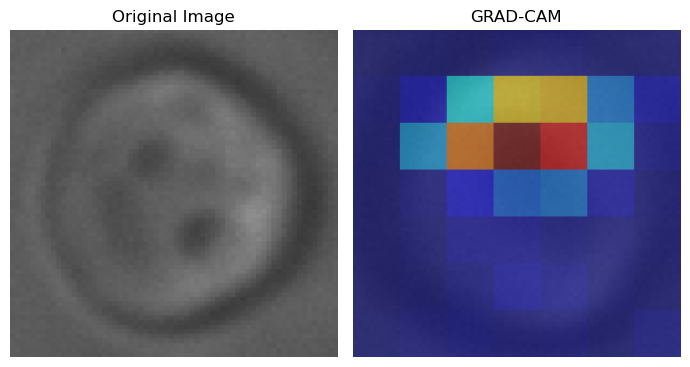

In [19]:
plot_two_images(img_base_nii, xai_gradcam_resnet,
                      title1="Original Image",title2="GRAD-CAM", save_path = "example-gradcam.png")

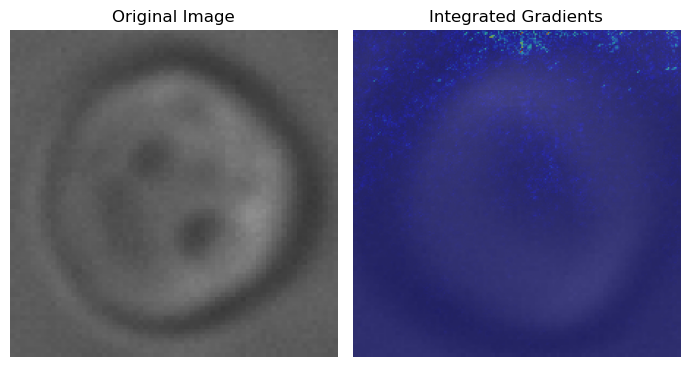

In [20]:
plot_two_images(img_base_nii, xai_ig_resnet,
                      title1="Original Image",title2="Integrated Gradients", save_path = "example-ig.png")

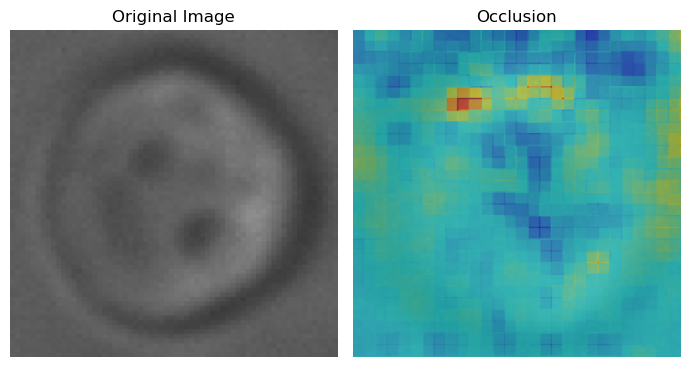

In [21]:
plot_two_images(img_base_nii, xai_occ_resnet,
                      title1="Original Image",title2="Occlusion", save_path = "example-occlusion.png")

## gerando imagem do cellpose

2025-11-18 19:43:47,145 [INFO] WRITING LOG OUTPUT TO C:\Users\sthem\.cellpose\run.log
2025-11-18 19:43:47,145 [INFO] 
cellpose version: 	4.0.8.dev11+g70c0d07d0 
platform:       	win32 
python version: 	3.10.16 
torch version:  	2.5.1
2025-11-18 19:43:47,292 [INFO] ** TORCH CUDA version installed and working. **
2025-11-18 19:43:47,293 [INFO] ** TORCH CUDA version installed and working. **
2025-11-18 19:43:47,294 [INFO] >>>> using GPU (CUDA)
2025-11-18 19:43:48,899 [INFO] >>>> loading model C:\Users\sthem\.cellpose\models\cpsam
Usando a imagem: C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_59_40.bmp


AttributeError: module 'cellpose.plot' has no attribute 'outlines_list'

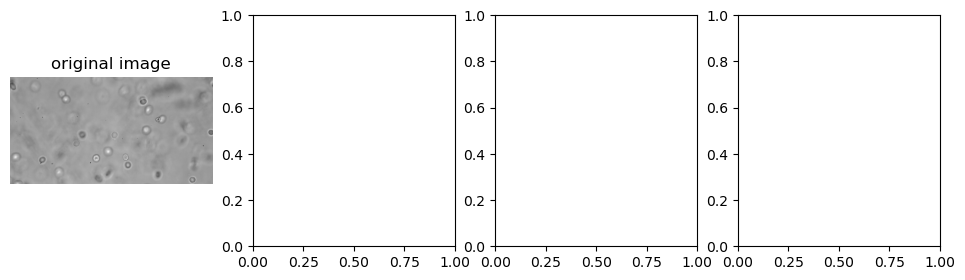

In [24]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
from skimage import io as io_skimage
import os

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage import io as io_skimage
from cellpose import plot

# escolhe uma imagem de exemplo (pode ser do train ou val)
example_path = r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train\2022_03_21_11_02_59_40.bmp"
print("Usando a imagem:", example_path)

# 1) carrega imagem original
img = io_skimage.imread(example_path)

# 2) roda o Cellpose nessa imagem
masks, flows, styles = model.eval(img, batch_size=1)

# 3) constrói as 4 colunas: original, outlines, masks, cell pose
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# --- coluna 1: imagem original ---
axes[0].imshow(img, cmap="gray")
axes[0].set_title("original image")
axes[0].axis("off")

# --- coluna 2: contornos (predicted outlines) ---
# usa função do cellpose pra desenhar contornos sobre a imagem
outlines = plot.outlines_list(masks)
img_outlines = plot.image_to_rgb(img, channels=[0,0])
img_outlines = plot.mask_overlay(img_outlines, masks, outline_color=(1,0,0))

axes[1].imshow(img_outlines)
axes[1].set_title("predicted outlines")
axes[1].axis("off")

# --- coluna 3: máscaras coloridas (label map) ---
axes[2].imshow(masks, cmap="nipy_spectral")
axes[2].set_title("predicted masks")
axes[2].axis("off")

# --- coluna 4: "predicted cell pose" (flows) ---
# geralmente flows[0] é o flow de células que o pessoal plota
flow_rgb = plot.flow_to_rgb(flows[0])
axes[3].imshow(flow_rgb)
axes[3].set_title("predicted cell pose")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("example_cellpose_fixed.png", dpi=300, bbox_inches="tight")
plt.show()


## nifti

NIFTI annotation


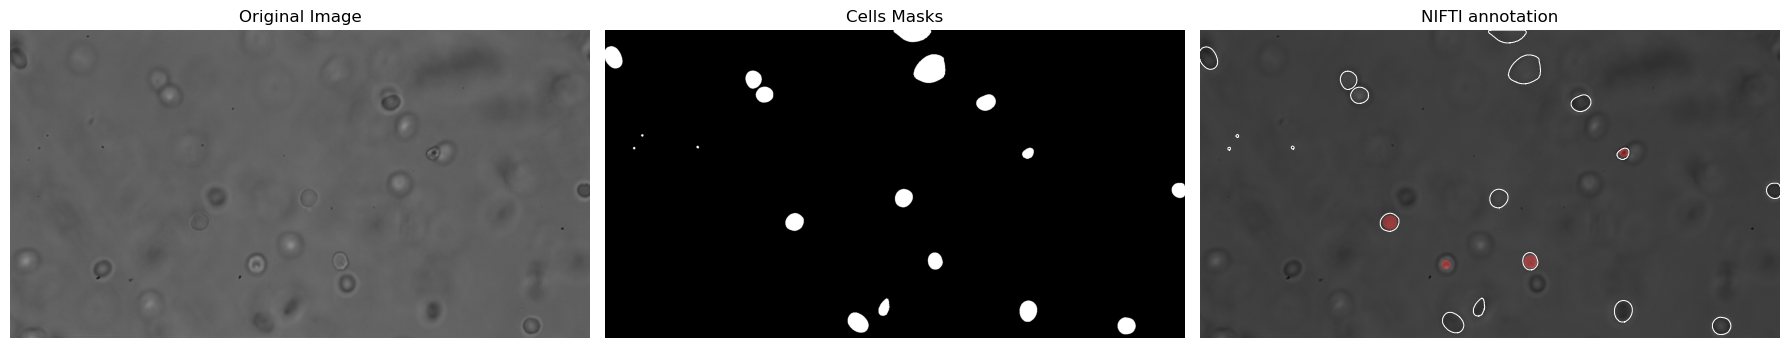

In [22]:
# ====== BUSCA AUTOMÁTICA DE SLICE + ORIENTAÇÃO PARA O NIFTI (FIX) ======
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as iio
import nibabel as nib
from skimage import measure
from scipy.ndimage import zoom

# ---- paths ----
img_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir\train")
mask_dir = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\img_dir_masks\train_masks\raw")
nii_dir  = Path(r"C:\Users\sthem\OneDrive\Documentos\GitHub\master-2025\3-Datasets\img-lcm\annot_dir_nii\train_segmentadas")
stem = "2022_03_21_11_02_59_40"

# ---- loaders ----
def load_img_rgb(p):   return np.array(Image.open(p).convert("RGB"), dtype=np.uint8)
def load_mask_ids(p):
    m = iio.imread(p)
    if m.ndim == 3: m = m[...,0]
    return m.astype(np.int32)

img  = load_img_rgb(img_dir/f"{stem}.bmp")
mask = load_mask_ids(next(iter(mask_dir.glob(f"{stem}*raw*.png")), mask_dir/f"{stem}_masks_raw.png"))
cell_union = (mask>0).astype(np.uint8)
H, W = mask.shape

nif   = nib.load(str(nii_dir/f"{stem}.nii.gz"))
arr3d = nif.get_fdata(dtype=np.float32)  # (H,W,Z) ou (W,H,Z)

def bin_slice(sl): return (sl>0).astype(np.uint8)

def candidates(a2d):
    return [
        ("id",           a2d),
        ("rot90",        np.rot90(a2d, 1)),
        ("rot180",       np.rot90(a2d, 2)),
        ("rot270",       np.rot90(a2d, 3)),
        ("transpose",    a2d.T),
        ("flipud",       np.flipud(a2d)),
        ("fliplr",       np.fliplr(a2d)),
        ("rot90+fliplr", np.fliplr(np.rot90(a2d,1))),
        ("rot90+flipud", np.flipud(np.rot90(a2d,1))),
    ]

best = {"score": -1, "k": None, "name": None, "res": None}

Z = arr3d.shape[-1] if arr3d.ndim==3 else 1
for k in range(Z):
    sl = arr3d[..., k] if arr3d.ndim==3 else arr3d
    sl = bin_slice(sl)

    # reamostra para (H,W)
    if sl.shape != (H,W):
        sl = zoom(sl, zoom=(H/sl.shape[0], W/sl.shape[1]), order=0)

    for name, cand in candidates(sl):
        # se a transf mudou o shape, reamostra de novo
        if cand.shape != (H,W):
            cand = zoom(cand, zoom=(H/cand.shape[0], W/cand.shape[1]), order=0)

        cand_bin = (cand>0).astype(np.uint8)
        inter = np.count_nonzero((cand_bin==1) & (cell_union==1))  # <<< FIX
        if inter > best["score"]:
            best.update(score=int(inter), k=k, name=name, res=cand_bin)

print(f"NIFTI annotation")

# --- visualização do melhor overlay ---
infected = best["res"].astype(np.uint8)
overlay  = img.astype(np.float32)/255.0
overlay_inf = np.zeros_like(overlay, dtype=np.float32)
overlay_inf[...,0] = infected  # canal R
alpha = 0.35
overlay = np.clip((1-alpha)*overlay + alpha*overlay_inf, 0, 1)

contours = measure.find_contours(mask, level=0.5)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(img); ax[0].set_title("Original Image"); ax[0].axis("off")
ax[1].imshow(mask>0, cmap="gray"); ax[1].set_title("Cells Masks"); ax[1].axis("off")
ax[2].imshow(overlay)
for c in contours: ax[2].plot(c[:,1], c[:,0], color="white", linewidth=0.7)
ax[2].set_title(f"NIFTI annotation")
ax[2].axis("off")
plt.tight_layout(); plt.show()
